In [1]:
import json
import numpy as np



with open("fit_values.json", "r") as f:
    values = json.load(f)
#Siamo riusciti a passare i dati dei fit al file json, ora possiamo usarli per fare i grafici.

#Interpoliamo le norme

masse=[25, 50, 75, 100, 125, 150, 175, 200]
fit_MH_values=values


<function matplotlib.pyplot.show(close=None, block=None)>

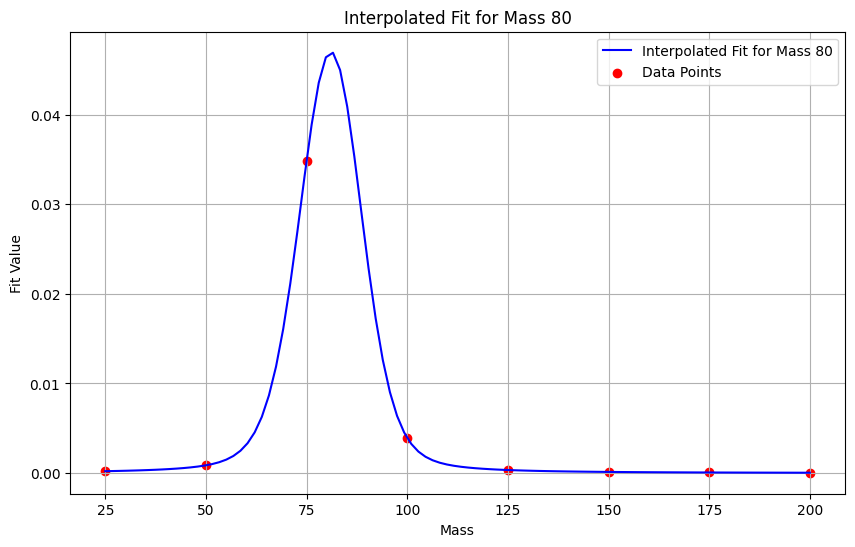

In [2]:
#prendiamo i valori dai file e cerchiamo di creare una  curva interpolata
from Utilities_copy import DoubleVoigtFit, voigt2
import matplotlib.pyplot as plt

DoubleVoigt_MH80=DoubleVoigtFit(80, fit_MH_values)

fit_parameters_80=DoubleVoigt_MH80.get_fit_parameters()

x_80=np.linspace(25, 200, 100)
y_80=voigt2(x_80, fit_parameters_80["norm"], fit_parameters_80["mu"], fit_parameters_80["sigma"], fit_parameters_80["gamma"], fit_parameters_80["norm2"], fit_parameters_80["mu2"], fit_parameters_80["sigma2"], fit_parameters_80["gamma2"])

plt.figure(figsize=(10, 6))
plt.plot(x_80, y_80, label='Interpolated Fit for Mass 80', color='blue')
plt.scatter(masse, [voigt2(m, fit_parameters_80["norm"], fit_parameters_80["mu"], fit_parameters_80["sigma"], fit_parameters_80["gamma"], fit_parameters_80["norm2"], fit_parameters_80["mu2"], fit_parameters_80["sigma2"], fit_parameters_80["gamma2"]) for m in masse], color='red', label='Data Points')
plt.title('Interpolated Fit for Mass 80')
plt.xlabel('Mass')
plt.ylabel('Fit Value')
plt.legend()
plt.grid()  
plt.show


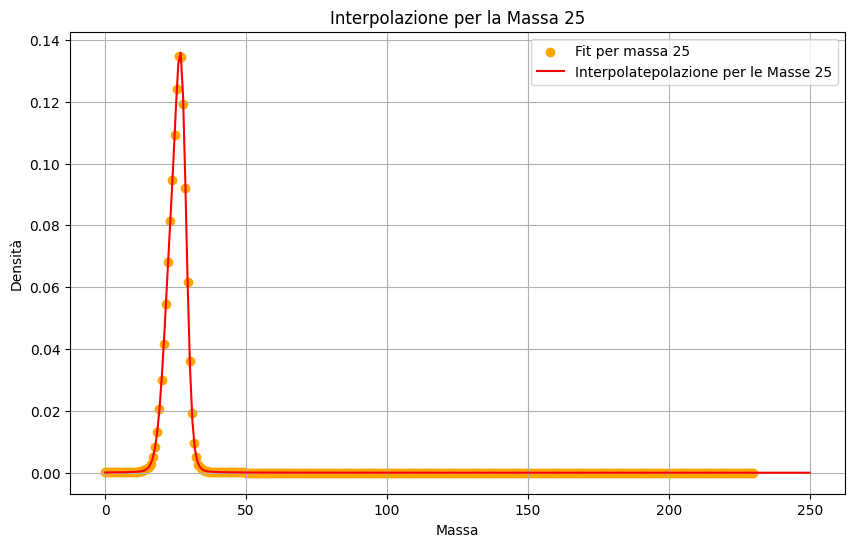

In [3]:
DoubleVoigt_MH25=DoubleVoigtFit(25, fit_MH_values, color='red')


x=np.linspace(0, 230, 300)
y_25=voigt2(x, fit_MH_values["MH25"]["norm"], fit_MH_values["MH25"]["mu"], fit_MH_values["MH25"]["sigma"], fit_MH_values["MH25"]["gamma"], 
         fit_MH_values["MH25"]["norm2"], fit_MH_values["MH25"]["mu2"], fit_MH_values["MH25"]["sigma2"], fit_MH_values["MH25"]["gamma2"])


fig, ax = plt.subplots(figsize=(10, 6))
plt.scatter(x, y_25, label='Fit per massa 25', color='orange')
DoubleVoigt_MH25.grafico(ax=ax)
plt.show()

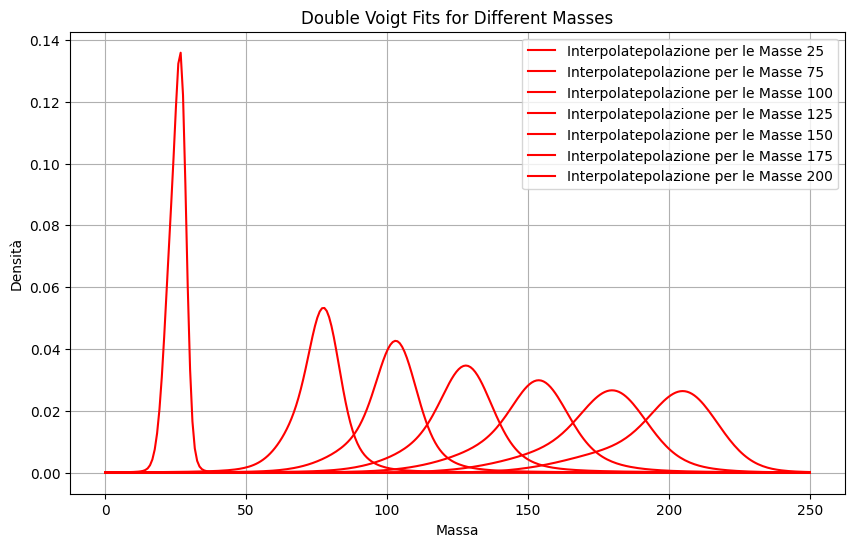

In [4]:
DoubleVoigt_MH50=DoubleVoigtFit(50, fit_MH_values, color='red')
DoubleVoigt_MH75=DoubleVoigtFit(75, fit_MH_values, color='red')
DoubleVoigt_MH100=DoubleVoigtFit(100, fit_MH_values, color='red')
DoubleVoigt_MH125=DoubleVoigtFit(125, fit_MH_values, color='red')
DoubleVoigt_MH150=DoubleVoigtFit(150, fit_MH_values, color='red')
DoubleVoigt_MH175=DoubleVoigtFit(175, fit_MH_values, color='red')
DoubleVoigt_MH200=DoubleVoigtFit(200, fit_MH_values, color='red')

fig, ax = plt.subplots(figsize=(10, 6))
DoubleVoigt_MH25.grafico(ax=ax, color='red')
#DoubleVoigt_MH50.grafico(ax=ax)
DoubleVoigt_MH75.grafico(ax=ax, color='red')
DoubleVoigt_MH100.grafico(ax=ax, color='red')        
DoubleVoigt_MH125.grafico(ax=ax, color='red')
DoubleVoigt_MH150.grafico(ax=ax, color='red')
DoubleVoigt_MH175.grafico(ax=ax, color='red')
DoubleVoigt_MH200.grafico(ax=ax, color='red')
plt.title('Double Voigt Fits for Different Masses')
plt.show()

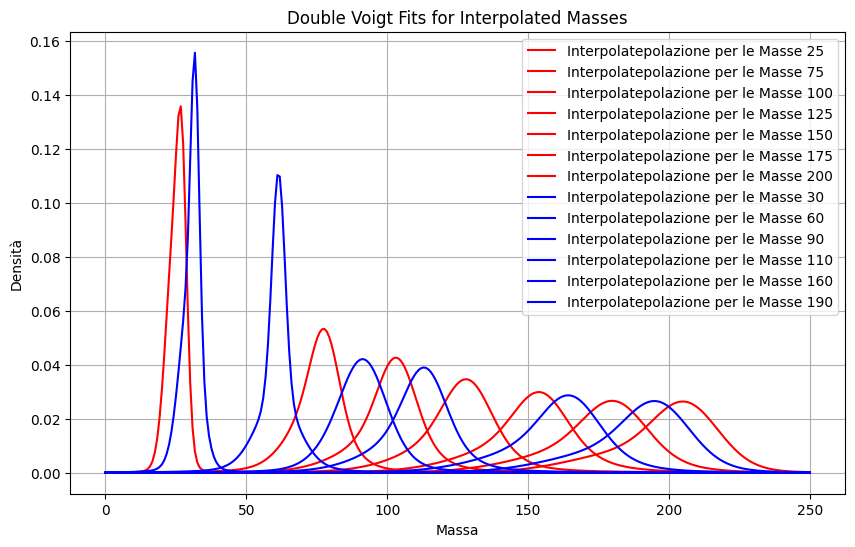

In [5]:
DoubleVoigt_MH30=DoubleVoigtFit(30, fit_MH_values, color='blue')
DoubleVoigt_MH60=DoubleVoigtFit(60, fit_MH_values, color='blue')
DoubleVoigt_MH90=DoubleVoigtFit(90, fit_MH_values, color='blue')
DoubleVoigt_MH110=DoubleVoigtFit(110, fit_MH_values, color='blue')
DoubleVoigt_MH160=DoubleVoigtFit(160, fit_MH_values, color='blue')
DoubleVoigt_MH190=DoubleVoigtFit(190, fit_MH_values, color='blue')

plt.figure(figsize=(20, 12))
DoubleVoigt_MH30.grafico(ax=ax,color='orange')
DoubleVoigt_MH60.grafico(ax=ax,color='blue')
DoubleVoigt_MH90.grafico(ax=ax,color='blue')     
DoubleVoigt_MH110.grafico(ax=ax,color='blue')
DoubleVoigt_MH160.grafico(ax=ax,color='blue')
DoubleVoigt_MH190.grafico(ax=ax,color='blue')
plt.title('Double Voigt Fits for Interpolated Masses')
plt.show()

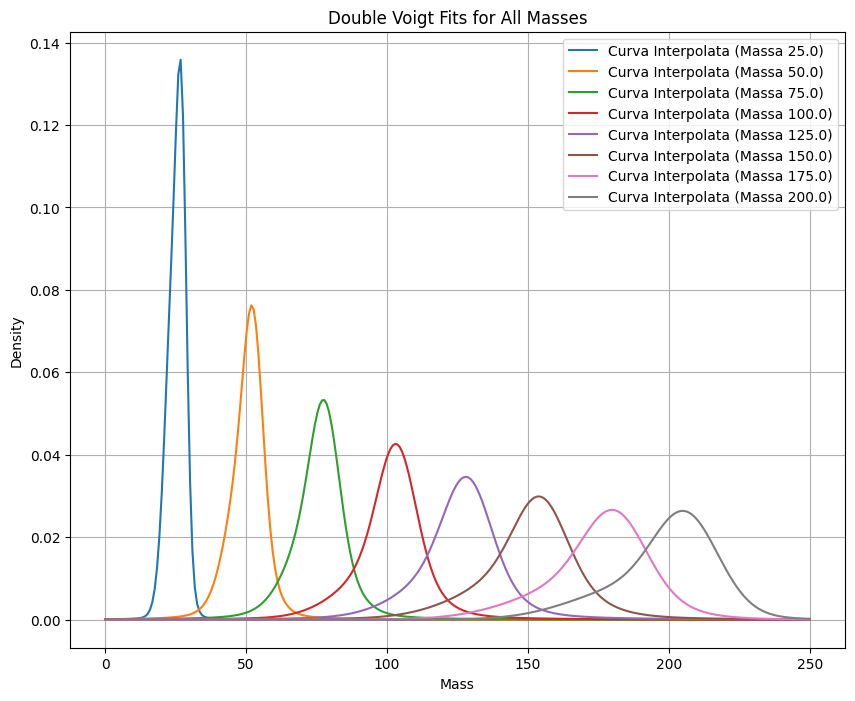

In [ ]:
from Utilities_copy import DoubleVoigtFit2
fig, ax= plt.subplots(figsize=(10, 8))
masse_dataset=[float(k.replace("MH", "")) for k in fit_MH_values.keys() if str(k).startswith("MH")]

for m in masse_dataset:
    double_voigt_fit = DoubleVoigtFit2(m, fit_MH_values, ax=ax)
    double_voigt_fit.grafico()

ax.set_title('Double Voigt Fits for All Masses')
ax.set_xlabel('Mass')
ax.set_ylabel('Density')
#ax.legend()
ax.grid(True)
plt.show()

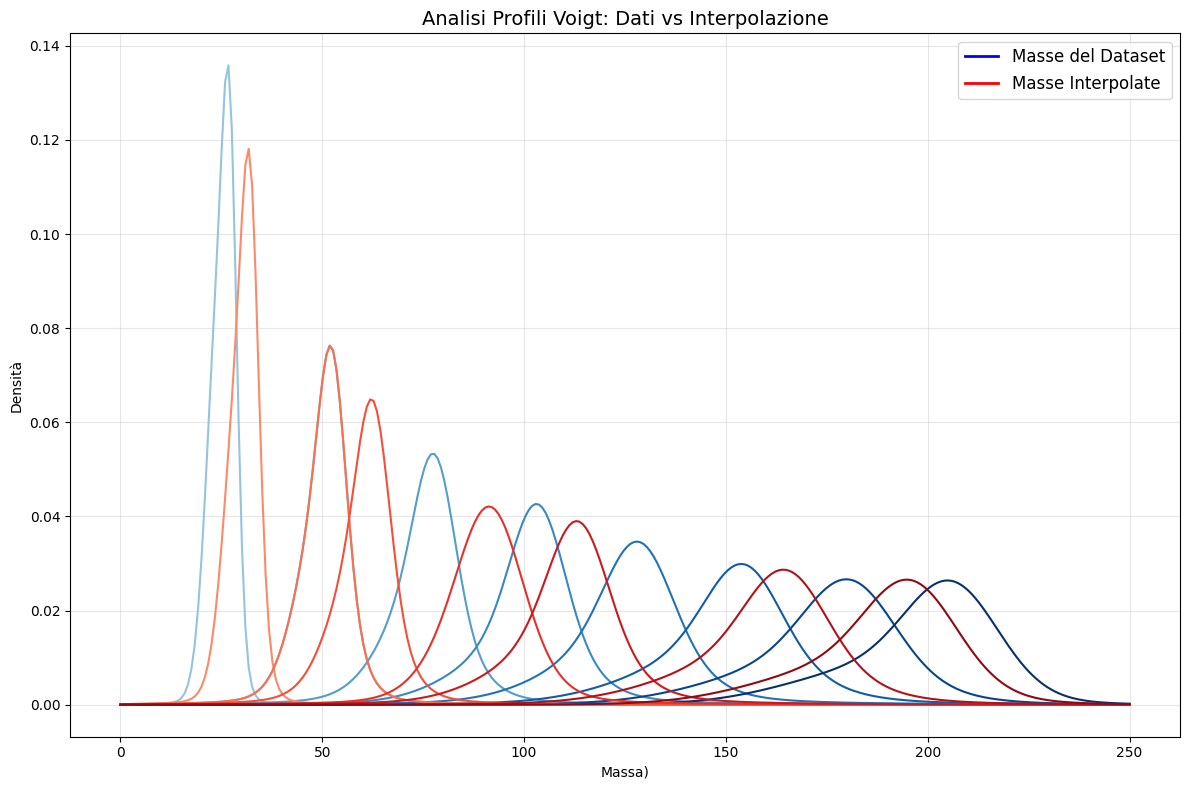

In [17]:
import matplotlib.cm as cm
from matplotlib.lines import Line2D


masse_interpolate=[30, 50, 60, 90, 110, 160, 190]
fig, ax = plt.subplots(figsize=(12, 8))
# Define a colormap
colori_blu=cm.Blues(np.linspace(0.4, 1, len(masse_dataset)))
colori_rossi=cm.Reds(np.linspace(0.4, 1, len(masse_dataset)))

for i, m in enumerate(masse_dataset):
    double_voigt_fit = DoubleVoigtFit2(m, fit_MH_values, ax=ax, color=colori_blu[i])
    double_voigt_fit.grafico()

for i, m in enumerate(masse_interpolate):
    double_voigt_fit = DoubleVoigtFit2(m, fit_MH_values, ax=ax, color=colori_rossi[i])
    double_voigt_fit.grafico()  

# Create custom legend
legend_elements = [Line2D([0], [0], color='blue', lw=2, label='Masse del Dataset'),
                   Line2D([0], [0], color='red', lw=2, label='Masse Interpolate')]

ax.legend(handles=legend_elements, fontsize=12)

ax.set_title("Analisi Profili Voigt: Dati vs Interpolazione", fontsize=14)
ax.set_xlabel("Massa)")
ax.set_ylabel("Densità")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()